In [15]:
import sys
print(sys.executable)


/Users/jaanya/pulsar-project/venv/bin/python


In [16]:
import pandas as pd
import numpy as np
import tensorflow as tf
import sklearn
print("All good")


All good


In [17]:
df = pd.read_csv('HTRU_2.csv', header=None)
df.columns = ['mean_ip','std_ip','kurt_ip','skew_ip', 'mean_dm','std_dm','kurt_dm','skew_dm','label']
df.head()

,mean_ip,std_ip,kurt_ip,skew_ip,mean_dm,std_dm,kurt_dm,skew_dm,label
0,140.562500,55.683782,-0.234571,-0.699648,3.199833,19.110426,7.975532,74.242225,0
1,102.507812,58.882430,0.465318,-0.515088,1.677258,14.860146,10.576487,127.393580,0
2,103.015625,39.341649,0.323328,1.051164,3.121237,21.744669,7.735822,63.171909,0
3,136.750000,57.178449,-0.068415,-0.636238,3.642977,20.959280,6.896499,53.593661,0
4,88.726562,40.672225,0.600866,1.123492,1.178930,11.468720,14.269573,252.567306,0


In [18]:
print(df.shape)
print(df['label'].value_counts())
print(df.isnull().sum())

(17898, 9)
label
0    16259
1     1639
Name: count, dtype: int64
mean_ip    0
std_ip     0
kurt_ip    0
skew_ip    0
mean_dm    0
std_dm     0
kurt_dm    0
skew_dm    0
label      0
dtype: int64


In [19]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop('label', axis=1).values
y = df['label'].values

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)
X_dev, X_test, y_dev, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_dev = scaler.transform(X_dev)
X_test = scaler.transform(X_test)

print(X_train.shape, X_dev.shape, X_test.shape)


(12528, 8) (2685, 8) (2685, 8)


In [20]:
print(y_train.mean(), y_dev.mean(), y_test.mean())

0.09155491698595147 0.09162011173184358 0.09162011173184358


In [21]:
from sklearn.utils.class_weight import compute_class_weight

weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = {0: weights[0], 1: weights[1]}
print(class_weights)

{0: np.float64(0.5503910025481065), 1: np.float64(5.461203138622493)}


In [22]:
histories = {}
models = {}

optimizer_configs = {
    'SGD': tf.keras.optimizers.SGD(learning_rate=0.01),
    'Momentum': tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
    'RMSprop': tf.keras.optimizers.RMSprop(learning_rate=0.001),
    'Adam': tf.keras.optimizers.Adam(learning_rate=0.001)
}

for name, opt in optimizer_configs.items():
    print(f"Training with {name}...")
    
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(16, activation='relu', kernel_initializer='he_normal', input_shape=(8,)),
        tf.keras.layers.Dense(8, activation='relu', kernel_initializer='he_normal'),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])
    
    model.compile(optimizer=opt, loss='binary_crossentropy', metrics=['accuracy'])
    
    history = model.fit(
        X_train, y_train,
        validation_data=(X_dev, y_dev),
        epochs=30,
        batch_size=32,
        class_weight=class_weights,
        verbose=0
    )
    
    histories[name] = history
    models[name] = model

print("Done training all 4 optimizers")

Training with SGD...


/Users/jaanya/pulsar-project/venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training with Momentum...
Training with RMSprop...
Training with Adam...
Done training all 4 optimizers


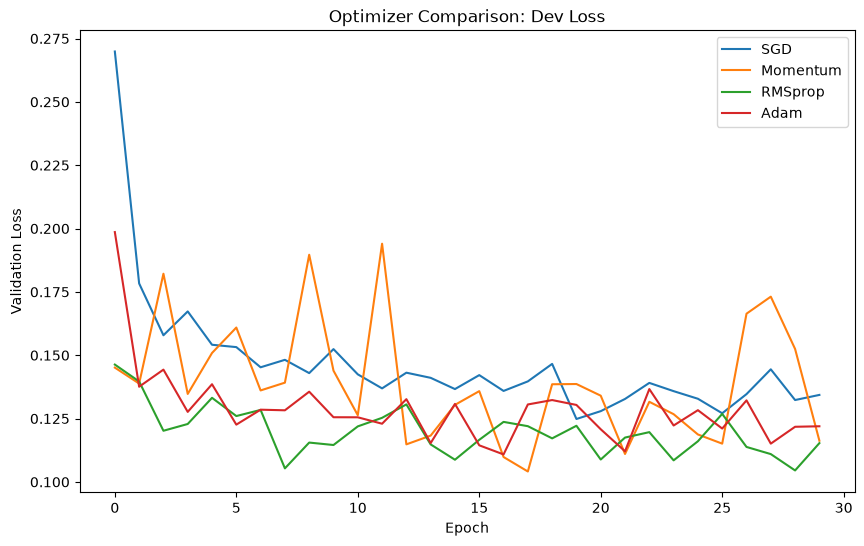

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
for name, history in histories.items():
    plt.plot(history.history['val_loss'], label=name)

plt.xlabel('Epoch')
plt.ylabel('Validation Loss')
plt.title('Optimizer Comparison: Dev Loss')
plt.legend()
plt.show()

In [24]:
from sklearn.metrics import classification_report

for name, model in models.items():
    y_pred_prob = model.predict(X_dev, verbose=0).flatten()
    y_pred = (y_pred_prob >= 0.5).astype(int)
    print(f"{name} ")
    print(classification_report(y_dev, y_pred, digits=3))

SGD 
              precision    recall  f1-score   support

           0      0.990     0.974     0.982      2439
           1      0.777     0.907     0.837       246

    accuracy                          0.968      2685
   macro avg      0.884     0.940     0.909      2685
weighted avg      0.971     0.968     0.969      2685

Momentum 
              precision    recall  f1-score   support

           0      0.991     0.977     0.984      2439
           1      0.801     0.915     0.854       246

    accuracy                          0.971      2685
   macro avg      0.896     0.946     0.919      2685
weighted avg      0.974     0.971     0.972      2685

RMSprop 
              precision    recall  f1-score   support

           0      0.989     0.978     0.984      2439
           1      0.806     0.894     0.848       246

    accuracy                          0.971      2685
   macro avg      0.898     0.936     0.916      2685
weighted avg      0.972     0.971     0.971      2

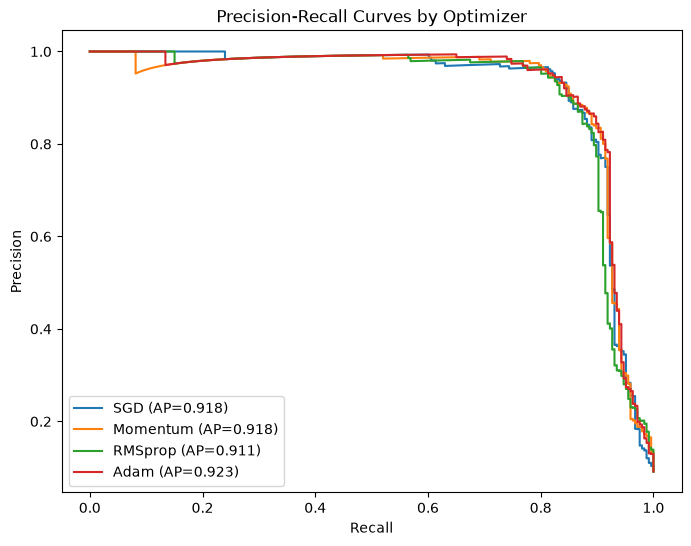

In [25]:
from sklearn.metrics import average_precision_score, precision_recall_curve
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
for name, model in models.items():
    y_pred_proba = model.predict(X_dev, verbose=0).flatten()
    precision, recall, _ = precision_recall_curve(y_dev, y_pred_proba)
    avgP_score = average_precision_score(y_dev, y_pred_proba)
    plt.plot(recall, precision, label=f"{name} (AP={avgP_score:.3f})")

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves by Optimizer')
plt.legend()
plt.show()

/Users/jaanya/pulsar-project/venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


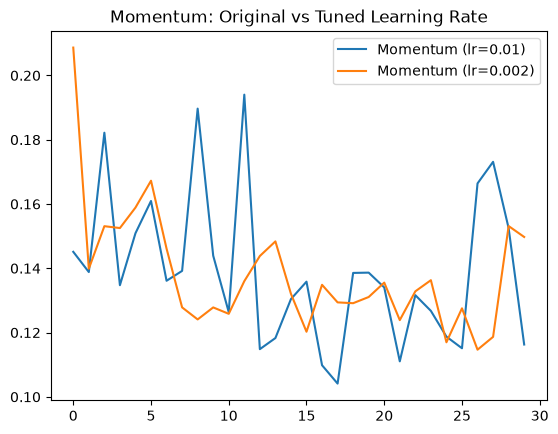

In [ ]:
modelM_tuned = tf.keras.Sequential([
    tf.keras.layers.Dense(16, activation='relu', kernel_initializer='he_normal', input_shape=(8,)),
    tf.keras.layers.Dense(8, activation='relu', kernel_initializer='he_normal'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

optM_tuned = tf.keras.optimizers.SGD(learning_rate=0.002, momentum=0.9)  # dropped from 0.01
modelM_tuned.compile(optimizer=optM_tuned, loss='binary_crossentropy', metrics=['accuracy'])

historyM_tuned = modelM_tuned.fit(
    X_train, y_train,
    validation_data=(X_dev, y_dev),
    epochs=30, batch_size=32,
    class_weight=class_weights,
    verbose=0
)

plt.plot(histories['Momentum'].history['val_loss'], label='Momentum (lr=0.01)')
plt.plot(historyM_tuned.history['val_loss'], label='Momentum (lr=0.002)')
plt.legend()
plt.title('Momentum: Original vs Tuned Learning Rate')
plt.show()

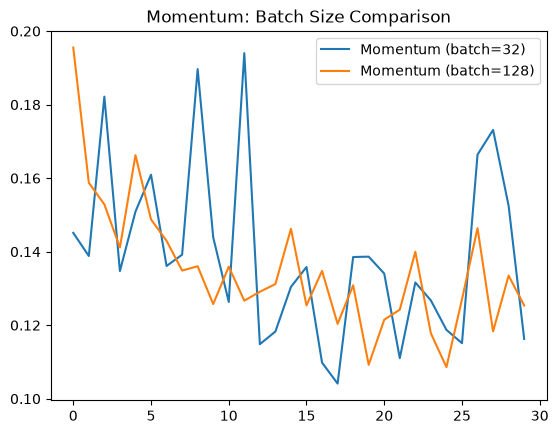

In [ ]:
modelM_bs128 = tf.keras.Sequential([
    tf.keras.layers.Dense(16, activation='relu', kernel_initializer='he_normal', input_shape=(8,)),
    tf.keras.layers.Dense(8, activation='relu', kernel_initializer='he_normal'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

optM_bs128 = tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9)
modelM_bs128.compile(optimizer=optM_bs128, loss='binary_crossentropy', metrics=['accuracy'])

historyM_bs128 = modelM_bs128.fit(
    X_train, y_train,
    validation_data=(X_dev, y_dev),
    epochs=30, batch_size=128,   # increased from 32
    class_weight=class_weights,
    verbose=0
)

plt.plot(histories['Momentum'].history['val_loss'], label='Momentum (batch=32)')
plt.plot(historyM_bs128.history['val_loss'], label='Momentum (batch=128)')
plt.legend()
plt.title('Momentum: Batch Size Comparison')
plt.show()

In [ ]:
from sklearn.metrics import precision_recall_curve

best_model = models['RMSprop']
y_pred_prob = best_model.predict(X_dev, verbose=0).flatten()
precision, recall, thresholds = precision_recall_curve(y_dev, y_pred_prob)

# find threshold where recall is high but precision doesn't get ruined
for p, r, t in zip(precision, recall, thresholds):
    if r >= 0.90:
        print(f"Threshold: {t:.3f}, Precision: {p:.3f}, Recall: {r:.3f}")
        

Threshold: 0.000, Precision: 0.092, Recall: 1.000
Threshold: 0.000, Precision: 0.092, Recall: 1.000
Threshold: 0.000, Precision: 0.092, Recall: 1.000
Threshold: 0.000, Precision: 0.092, Recall: 1.000
Threshold: 0.000, Precision: 0.092, Recall: 1.000
Threshold: 0.000, Precision: 0.092, Recall: 1.000
Threshold: 0.000, Precision: 0.092, Recall: 1.000
Threshold: 0.000, Precision: 0.092, Recall: 1.000
Threshold: 0.000, Precision: 0.092, Recall: 1.000
Threshold: 0.000, Precision: 0.092, Recall: 1.000
Threshold: 0.000, Precision: 0.092, Recall: 1.000
Threshold: 0.000, Precision: 0.092, Recall: 1.000
Threshold: 0.000, Precision: 0.092, Recall: 1.000
Threshold: 0.000, Precision: 0.092, Recall: 1.000
Threshold: 0.000, Precision: 0.092, Recall: 1.000
Threshold: 0.000, Precision: 0.092, Recall: 1.000
Threshold: 0.000, Precision: 0.092, Recall: 1.000
Threshold: 0.000, Precision: 0.092, Recall: 1.000
Threshold: 0.000, Precision: 0.092, Recall: 1.000
Threshold: 0.000, Precision: 0.092, Recall: 1.000


In [32]:
from sklearn.metrics import precision_recall_curve
import numpy as np

y_pred_proba = models['Adam'].predict(X_dev, verbose=0).flatten()
precision, recall, thresholds = precision_recall_curve(y_dev, y_pred_proba)

mask = recall[:-1] >= 0.90
valid_precisions = precision[:-1][mask]
valid_thresholds = thresholds[mask]
valid_recalls = recall[:-1][mask]

best_idx = np.argmax(valid_precisions)
print(f"Best threshold: {valid_thresholds[best_idx]:.3f}")
print(f"Precision: {valid_precisions[best_idx]:.3f}")
print(f"Recall: {valid_recalls[best_idx]:.3f}")

Best threshold: 0.626
Precision: 0.844
Recall: 0.902


In [34]:
best_threshold = 0.626

y_test_proba = models['Adam'].predict(X_test, verbose=0).flatten()
y_test_pred = (y_test_proba >= best_threshold).astype(int)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_test_pred, digits=3))

              precision    recall  f1-score   support

           0      0.992     0.979     0.986      2439
           1      0.819     0.923     0.868       246

    accuracy                          0.974      2685
   macro avg      0.906     0.951     0.927      2685
weighted avg      0.976     0.974     0.975      2685

